# Stage 07: Outliers and Risk Assumptions

This notebook examines potential outliers in the Stage 06 S&P 500 daily-return series. It compares IQR filtering and winsorization against the unchanged data, then documents the limits of these choices.

## Thresholds and Scope

- IQR: Tukey multiplier `1.5`
- Z-score: absolute threshold `3.0`
- Winsorization: 5th/95th percentiles
- Sensitivity model: daily return explained by standardized volume, used only to show how treatment choices change summary estimates

The first Stage 06 return is excluded because it was set to zero solely due to the lack of a preceding close.

In [1]:
from datetime import datetime, timezone
import json
import os
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

REPO_ROOT = next(
    parent for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / 'homework' / 'homework07').exists()
)
HOMEWORK_DIR = REPO_ROOT / 'homework' / 'homework07'
load_dotenv(HOMEWORK_DIR / '.env')
PROCESSED_DIR = HOMEWORK_DIR / os.environ.get('DATA_DIR_PROCESSED', 'data/processed')
REPORTS_DIR = HOMEWORK_DIR / os.environ.get('REPORTS_DIR', 'reports')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(HOMEWORK_DIR / 'src'))
from outlier_utils import (
    detect_outliers_iqr, detect_outliers_zscore, fit_return_sensitivity,
    iqr_bounds, winsorize_series,
)

RUN_TIMESTAMP = datetime.now(timezone.utc).strftime('%Y%m%d-%H%M%S')

/Users/yifang/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /var/folders/s5/8svqh9px7c37nc9bv7gsq6gh0000gn/T/matplotlib-qc647r3_ because there was an issue with the default path (/Users/yifang/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


## Load Analysis-Ready Data
The input is the Stage 06 validated Parquet file. The first artificial zero return is excluded from risk analysis.

In [2]:
stage06_processed_dir = REPO_ROOT / 'homework' / 'homework06' / 'data' / 'processed'
source_files = sorted(stage06_processed_dir.glob('sp500_prices_cleaned_*.parquet'))
if not source_files:
    raise FileNotFoundError('Run the Stage 06 notebook first so cleaned data are available.')

source_path = source_files[-1]
cleaned_prices = pd.read_parquet(source_path).sort_values('date').reset_index(drop=True)
analysis_data = cleaned_prices.iloc[1:].copy().reset_index(drop=True)
analysis_data[['date', 'daily_return', 'volume_zscore']].head()

/Users/runner/work/crossbow/crossbow/arrow/cpp/src/arrow/util/cpu_info.cc:239: IOError: sysctlbyname failed for 'hw.l1dcachesize'. Detail: [errno 1] Operation not permitted
/Users/runner/work/crossbow/crossbow/arrow/cpp/src/arrow/util/cpu_info.cc:239: IOError: sysctlbyname failed for 'hw.l2cachesize'. Detail: [errno 1] Operation not permitted
/Users/runner/work/crossbow/crossbow/arrow/cpp/src/arrow/util/cpu_info.cc:239: IOError: sysctlbyname failed for 'hw.l3cachesize'. Detail: [errno 1] Operation not permitted
/Users/runner/work/crossbow/crossbow/arrow/cpp/src/arrow/util/cpu_info.cc:239: IOError: sysctlbyname failed for 'hw.optional.neon'. Detail: [errno 1] Operation not permitted


,date,daily_return,volume_zscore
0,2025-01-03,0.012596,-2.184069
1,2025-01-06,0.005538,1.612337
2,2025-01-07,-0.011104,0.351253
3,2025-01-08,-0.004625,0.125786
4,2025-01-10,-0.009293,1.051010


## Detect Outliers
IQR is distribution-robust but threshold dependent. Z-score is sensitive to non-normal or heavy-tailed returns. Both flags are retained for auditability.

In [3]:
IQR_MULTIPLIER = 1.5
Z_THRESHOLD = 3.0
lower_fence, upper_fence = iqr_bounds(analysis_data['daily_return'], IQR_MULTIPLIER)
analysis_data['outlier_iqr'] = detect_outliers_iqr(analysis_data['daily_return'], IQR_MULTIPLIER)
analysis_data['outlier_zscore'] = detect_outliers_zscore(analysis_data['daily_return'], Z_THRESHOLD)
analysis_data['return_zscore'] = (
    (analysis_data['daily_return'] - analysis_data['daily_return'].mean())
    / analysis_data['daily_return'].std(ddof=0)
)

flag_summary = {
    'iqr_outliers': int(analysis_data['outlier_iqr'].sum()),
    'zscore_outliers': int(analysis_data['outlier_zscore'].sum()),
    'iqr_lower_fence': lower_fence,
    'iqr_upper_fence': upper_fence,
}
flag_summary

{'iqr_outliers': 0,
 'zscore_outliers': 0,
 'iqr_lower_fence': -0.020645584667309536,
 'iqr_upper_fence': 0.021968144623136954}

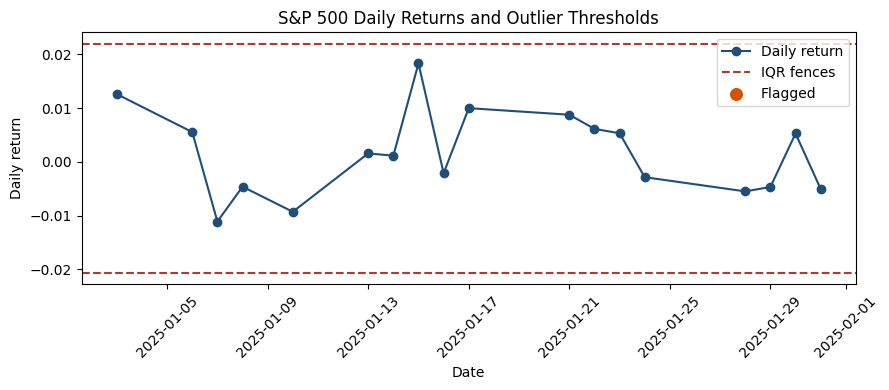

In [4]:
plt.figure(figsize=(9, 4))
plt.plot(analysis_data['date'], analysis_data['daily_return'], marker='o', color='#1f4e79', label='Daily return')
plt.axhline(lower_fence, linestyle='--', color='#b03a2e', label='IQR fences')
plt.axhline(upper_fence, linestyle='--', color='#b03a2e')
flagged = analysis_data[analysis_data['outlier_iqr'] | analysis_data['outlier_zscore']]
plt.scatter(flagged['date'], flagged['daily_return'], color='#d35400', s=70, label='Flagged')
plt.title('S&P 500 Daily Returns and Outlier Thresholds')
plt.xlabel('Date')
plt.ylabel('Daily return')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
outlier_plot_path = REPORTS_DIR / f'daily_return_outliers_{RUN_TIMESTAMP}.png'
plt.savefig(outlier_plot_path, dpi=150)
plt.show()

## Treatment Sensitivity Analysis
All data retain every observation. IQR filtering removes only IQR flags. Winsorization retains all rows while clipping the most extreme 5% in each tail.

In [5]:
winsorized_data = analysis_data.copy()
winsorized_data['daily_return'] = winsorize_series(winsorized_data['daily_return'], 0.05, 0.95)
filtered_data = analysis_data.loc[~analysis_data['outlier_iqr']].copy()

sensitivity_metrics = pd.DataFrame([
    {'treatment': 'all_data', **fit_return_sensitivity(analysis_data)},
    {'treatment': 'filtered_iqr', **fit_return_sensitivity(filtered_data)},
    {'treatment': 'winsorized_5_95', **fit_return_sensitivity(winsorized_data)},
])
sensitivity_metrics

,treatment,observations,slope,intercept,r2,mae,return_mean,return_std
0,all_data,18,-0.001675,0.001852,0.034838,0.006577,0.001636,0.007717
1,filtered_iqr,18,-0.001675,0.001852,0.034838,0.006577,0.001636,0.007717
2,winsorized_5_95,18,-0.001760,0.001678,0.046020,0.006204,0.001451,0.007056


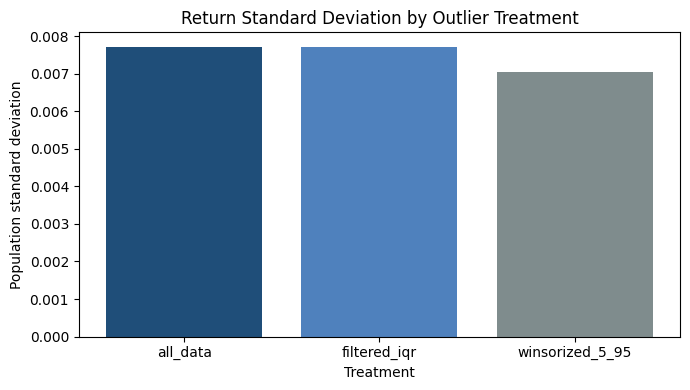

In [6]:
plt.figure(figsize=(7, 4))
plt.bar(sensitivity_metrics['treatment'], sensitivity_metrics['return_std'], color=['#1f4e79', '#4f81bd', '#7f8c8d'])
plt.title('Return Standard Deviation by Outlier Treatment')
plt.xlabel('Treatment')
plt.ylabel('Population standard deviation')
plt.tight_layout()
sensitivity_plot_path = REPORTS_DIR / f'sensitivity_return_std_{RUN_TIMESTAMP}.png'
plt.savefig(sensitivity_plot_path, dpi=150)
plt.show()

## Save Results and Risk Record
The flag table and sensitivity metrics are saved for reproducibility. The separate Markdown file records risk assumptions in a stakeholder-readable form.

In [7]:
flags_path = PROCESSED_DIR / f'daily_return_outlier_flags_{RUN_TIMESTAMP}.csv'
sensitivity_path = PROCESSED_DIR / f'sensitivity_metrics_{RUN_TIMESTAMP}.csv'
metadata_path = PROCESSED_DIR / f'outlier_analysis_metadata_{RUN_TIMESTAMP}.json'
analysis_data.to_csv(flags_path, index=False)
sensitivity_metrics.to_csv(sensitivity_path, index=False)
metadata = {
    'source_file': str(source_path.relative_to(REPO_ROOT)),
    'observations_analyzed': int(len(analysis_data)),
    'thresholds': {'iqr_multiplier': IQR_MULTIPLIER, 'zscore_threshold': Z_THRESHOLD, 'winsor_quantiles': [0.05, 0.95]},
    'flag_summary': flag_summary,
    'outputs': {
        'flags': str(flags_path.relative_to(REPO_ROOT)),
        'sensitivity_metrics': str(sensitivity_path.relative_to(REPO_ROOT)),
        'outlier_plot': str(outlier_plot_path.relative_to(REPO_ROOT)),
        'sensitivity_plot': str(sensitivity_plot_path.relative_to(REPO_ROOT)),
    },
}
metadata_path.write_text(json.dumps(metadata, indent=2), encoding='utf-8')

assert pd.read_csv(flags_path).shape[0] == len(analysis_data)
assert pd.read_csv(sensitivity_path).shape[0] == 3
print('Saved results:', flags_path.name, sensitivity_path.name, metadata_path.name)

Saved results: daily_return_outlier_flags_20260820-050805.csv sensitivity_metrics_20260820-050805.csv outlier_analysis_metadata_20260820-050805.json


## Risk Interpretation

No observations are flagged by the selected IQR or Z-score rules in this short sample. This does not imply that S&P 500 returns lack tail risk. It means only that, within this January 2025 sample and these thresholds, no observation crossed the selected fences.

For risk management, rare large moves can be the most decision-relevant data. The project therefore retains the original observations, reports the sensitivity table, and postpones any irreversible filtering decision until a longer historical dataset and stakeholder use case are available.